<a href="https://colab.research.google.com/github/sahdahx/PDS/blob/main/PDS_T4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas 4: Descriptive Statistics & Summaries - Pengantar Data Sains**
**Analisis Statistik Dataset Gaming and Mental Health**

> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

> email: sahdahuwaidahestiningtyas@mail.ugm.ac.id

# **Assignment - Week 5**

Gunakan **1 dataset publik** yang Anda pilih sendiri, lalu kerjakan analisis statistika deskriptif dengan tahapan berikut.

### 1. Jelaskan sumber dataset
Tuliskan informasi berikut:
- **nama dataset**
- **link sumber**
- **periode data**
- **unit analisis**
- **arti variabel utama**

### 2. Muat dataset ke Python
Gunakan `pandas`, lalu tampilkan:
- `shape`
- `head()`
- `info()`
- `describe()`

### 3. Lakukan pemeriksaan kualitas data
Lakukan pengecekan berikut:
- **missing values**
- **data duplikat**
- **nilai yang tidak wajar** pada variabel utama

### 4. Hitung statistik deskriptif
Pilih **minimal 2 variabel numerik**, lalu hitung:
- **mean**
- **median**
- **mode** *(jika relevan)*
- **range**
- **variance**
- **standard deviation**
- **IQR**
- **five-number summary**
- **skewness**
- **kurtosis**
- **outlier** dengan aturan **1.5 × IQR**

### 5. Analisis variabel kategorik
Jika ada variabel kategorik, buat:
- **tabel frekuensi**
- **proporsi**
- **ringkasan numerik per kelompok**

### 6. Tulis interpretasi hasil
Tuliskan interpretasi yang mencakup:
- **bentuk distribusi**
- **penyebaran data**
- **outlier**
- **hubungan antar variabel**
- **rekomendasi ringkasan statistik yang paling sesuai**

### 7. Tulis kesimpulan akhir
Tuliskan **kesimpulan akhir** secara singkat dan jelas.

## Ketentuan pengumpulan
Mahasiswa mengumpulkan:
1. **Notebook** (`.ipynb`) yang berisi seluruh proses analisis.
2. **Laporan singkat** (`.pdf` atau `.docx`) yang memuat ringkasan hasil, visualisasi, interpretasi, dan kesimpulan.
3. **File dataset** yang digunakan, jika ukuran file memungkinkan.

## 1) Deskripsi Dataset

Dataset yang digunakan adalah **Gaming and Mental Health** yang tersedia di Kaggle.

Link sumber: https://www.kaggle.com/datasets/shaistashahid/gaming-and-mental-health

Dataset ini tidak secara spesifik mencantumkan periode waktu pengambilan data sehingga dapat diasumsikan sebagai data cross-sectional (potret pada satu waktu tertentu).

Unit analisis pada dataset ini adalah **individu (gamer)**, di mana setiap baris merepresentasikan satu responden dengan berbagai karakteristik terkait aktivitas gaming dan kondisi kesehariannya.

Variabel utama dalam dataset meliputi:

* `daily_gaming_hours`: durasi bermain game per hari
* `sleep_hours` dan `sleep_quality`: indikator pola dan kualitas tidur
* `grades_gpa` dan `work_productivity_score`: performa akademik dan produktivitas
* `social_isolation_score`: tingkat isolasi sosial
* `gaming_addiction_risk_level`: tingkat risiko kecanduan game


In [ ]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

## 2) Muat Dataset ke Python

Dataset dimuat menggunakan library `pandas` ke dalam DataFrame `df`.
Beberapa fungsi dasar digunakan untuk memahami struktur data:

* `df.shape` untuk mengetahui jumlah baris dan kolom (1000, 27)
* `df.head()` untuk melihat 5 data teratas
* `df.info()` untuk melihat tipe data dan kelengkapan data
* `df.describe()` untuk melihat ringkasan statistik variabel numerik

Tahap ini bertujuan untuk memahami gambaran awal dataset sebelum dilakukan analisis lebih lanjut.

In [ ]:
# Membaca data
df = pd.read_csv("Gaming and Mental Health.csv")
df

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,False,0.8,8.4,1,12.7,22.02,8,Low


In [ ]:
# Jumlah baris dan kolom
df.shape

(1000, 27)

In [ ]:
# Tampilan 5 data pertama
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [ ]:
# Struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [ ]:
# Statistik deskriptif
df.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


## 3) Pemeriksaan Kualitas Data

Pemeriksaan kualitas data dilakukan untuk memastikan data layak dianalisis.

* **Missing values**

  Ditemukan missing value pada:

  * `grades_gpa` (24,6%)
  * `work_productivity_score` (32,6%)
    Penanganan dilakukan dengan imputasi median agar tidak mengurangi jumlah data.

* **Data duplikat**

  Dilakukan pengecekan menggunakan `df.duplicated()`. Tidak ditemukan duplikasi sehingga tidak diperlukan penghapusan data.

* **Nilai tidak wajar**

  Dilihat pada variabel utama seperti `daily_gaming_hours`. Ditemukan beberapa nilai ekstrem (outlier), tetapi masih dalam batas realistis sehingga tetap dipertahankan.

Tahap ini bertujuan untuk memastikan data bersih, konsisten, dan tidak menimbulkan bias.


In [ ]:
# Cek missing values
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)
missing_table

,missing_count,missing_percent
work_productivity_score,326,32.6
grades_gpa,246,24.6
record_id,0,0.0
daily_gaming_hours,0,0.0
game_genre,0,0.0
primary_game,0,0.0
gaming_platform,0,0.0
sleep_hours,0,0.0
sleep_quality,0,0.0
age,0,0.0


In [ ]:
# Tentukan kolom numerik dan kategorik
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

print("Kolom numerik:")
for col in numeric_cols:
    print("-", col)

print("\nKolom kategorik:")
for col in categorical_cols:
    print("-", col)

Kolom numerik:
- age
- daily_gaming_hours
- sleep_hours
- grades_gpa
- work_productivity_score
- weight_change_kg
- exercise_hours_weekly
- social_isolation_score
- face_to_face_social_hours_weekly
- monthly_game_spending_usd
- years_gaming

Kolom kategorik:
- record_id
- gender
- game_genre
- primary_game
- gaming_platform
- sleep_quality
- sleep_disruption_frequency
- academic_work_performance
- mood_state
- mood_swing_frequency
- withdrawal_symptoms
- loss_of_other_interests
- continued_despite_problems
- eye_strain
- back_neck_pain
- gaming_addiction_risk_level


## 4) Statistik Deskriptif

Statistik deskriptif dilakukan pada variabel numerik seperti untuk memahami karakteristik data.

Beberapa ukuran yang digunakan:

* **mean, median, mode** untuk menggambarkan nilai pusat data
* **range, variance, standard deviation** untuk menunjukkan penyebaran data
* **IQR dan five-number summary** untuk membantu melihat distribusi data secara lebih detail
* **skewness** untuk menunjukkan kemiringan distribusi
* **kurtosis** untuk menunjukkan tingkat keruncingan distribusi
* **outlier (1.5 × IQR)** untuk mengidentifikasi nilai ekstrem


In [ ]:
# Ringkasan statistik deskriptif untuk variabel numerik
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.475000,4.116105,13.00,18.0000,20.000,22.0000,35.00
daily_gaming_hours,1000.0,6.151400,2.867194,0.50,4.1000,6.000,8.0250,15.10
sleep_hours,1000.0,5.738100,1.441213,3.00,4.8000,5.700,6.6000,9.00
grades_gpa,754.0,2.518037,0.872312,1.01,1.7600,2.530,3.2800,4.00
work_productivity_score,674.0,5.394659,2.898742,1.00,3.0000,5.000,8.0000,10.00
weight_change_kg,1000.0,1.513400,1.432212,0.00,0.4000,1.100,2.1000,8.90
exercise_hours_weekly,1000.0,6.945900,1.805027,0.70,5.7000,7.000,8.2000,11.50
social_isolation_score,1000.0,3.872000,2.091409,1.00,2.0000,4.000,5.0000,10.00
face_to_face_social_hours_weekly,1000.0,7.654500,3.751954,0.00,5.0000,8.000,10.4000,16.70
monthly_game_spending_usd,1000.0,105.219730,113.886768,0.10,32.5925,66.405,126.2425,499.27


In [ ]:
# Memilih variabel utama untuk dianalisis
target = "daily_gaming_hours" if "daily_gaming_hours" in df.columns else numeric_cols[0]
x = df[target].dropna()

print("Variabel utama yang dipakai:", target)
print("Jumlah data valid:", len(x))

Variabel utama yang dipakai: daily_gaming_hours
Jumlah data valid: 1000


In [ ]:
# Cek mean
mean_value = x.mean()
print(f"Mean {target} = {mean_value:.4f}")

# Cek median
median_value = x.median()
print(f"Median {target} = {median_value:.4f}")

# Cek modus
mode_values = x.mode()
if len(mode_values) > 0:
    print(f"Mode pertama = {mode_values.iloc[0]:.4f}")

# Interpretasi
print("Interpretasi:")
if mean_value > median_value:
    print("Karena nilai mean lebih besar dari median, maka distribusi sering cenderung miring ke kanan (right-skewed)")
elif mean_value < median_value:
    print("Karena nilai mean lebih kecil dari median, maka distribusi sering cenderung miring ke kiri (left-skewed)")
else:
    print("Karena nilai mean hampir sama dengan median, maka distribusi cenderung cukup simetris.")

Mean daily_gaming_hours = 6.1514
Median daily_gaming_hours = 6.0000
Mode pertama = 5.8000
Interpretasi:
Karena nilai mean lebih besar dari median, maka distribusi sering cenderung miring ke kanan (right-skewed)


In [ ]:
# Cek range
range_value = x.max() - x.min()
print(f"Range {target} = {range_value:.4f}")

# Cek variance
variance_value = x.var(ddof=1)   # sample variance
print(f"Sample variance {target} = {variance_value:.4f}")

# Cek standar deviasi
std_value = x.std(ddof=1)   # sample standard deviation
print(f"Sample standard deviation {target} = {std_value:.4f}")

Range daily_gaming_hours = 14.6000
Sample variance daily_gaming_hours = 8.2208
Sample standard deviation daily_gaming_hours = 2.8672


In [ ]:
# Cek outlier menggunakan IQR
q1 = x.quantile(0.25)
q2 = x.quantile(0.50)
q3 = x.quantile(0.75)
iqr_value = q3 - q1

print(f"Q1  = {q1:.4f}")
print(f"Q2  = {q2:.4f}")
print(f"Q3  = {q3:.4f}")
print(f"IQR = {iqr_value:.4f}")

outliers = df[
    (df['daily_gaming_hours'] < lower_bound) |
    (df['daily_gaming_hours'] > upper_bound)
]
print("Jumlah outlier =",outliers.shape[0])

Q1  = 4.1000
Q2  = 6.0000
Q3  = 8.0250
IQR = 3.9250
Jumlah outlier = 6


In [ ]:
# Ringkasan ukuran penyebaran
cv_value = (std_value / mean_value) * 100 if mean_value != 0 else np.nan

summary_dispersion = pd.DataFrame({
    "Ukuran": ["Range", "Variance", "Standard Deviation", "IQR", "Coefficient of Variation (%)"],
    "Nilai": [range_value, variance_value, std_value, iqr_value, cv_value]
})
summary_dispersion

,Ukuran,Nilai
0,Range,14.600000
1,Variance,8.220799
2,Standard Deviation,2.867194
3,IQR,3.925000
4,Coefficient of Variation (%),46.610423


In [ ]:
# Ringkasan five-number summary
five_number_summary = pd.DataFrame({
    "component": ["minimum", "Q1", "median", "Q3", "maximum"],
    "value": [x.min(), q1, median_value, q3, x.max()]
})
five_number_summary

,component,value
0,minimum,0.500
1,Q1,4.100
2,median,6.000
3,Q3,8.025
4,maximum,15.100


In [ ]:
# Cek skewness
skewness_value = x.skew()
print(f"Skewness {target}: {skewness_value:.4f}")

# Cek kurtosis
kurtosis_value = x.kurt()
print(f"Kurtosis {target}: {kurtosis_value:.4f}")

Skewness daily_gaming_hours: 0.3508
Kurtosis daily_gaming_hours: -0.1812


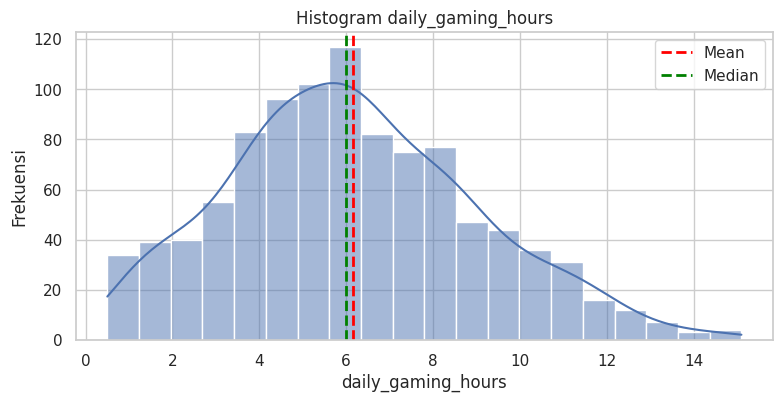

In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(x, bins=20, kde=True)
plt.axvline(mean_value, color="red", linestyle="--", linewidth=2, label="Mean")
plt.axvline(median_value, color="green", linestyle="--", linewidth=2, label="Median")
plt.title(f"Histogram {target}")
plt.xlabel(target)
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

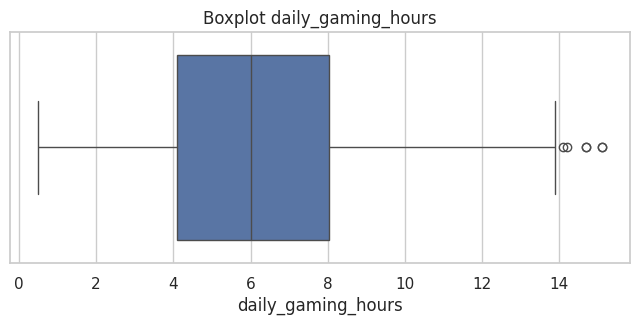

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=x)
plt.title(f"Boxplot {target}")
plt.xlabel(target)
plt.show()

## 5) Analisis Variabel Kategorik

Metode yang digunakan:

* **tabel frekuensi** → untuk melihat jumlah tiap kategori
* **proporsi** → untuk mengetahui distribusi dalam bentuk persentase
* **ringkasan numerik per kelompok** → misalnya rata-rata `daily_gaming_hours` berdasarkan kategori tertentu

Hasil analisis membantu memahami pola distribusi kategori, misalnya kategori risiko kecanduan atau preferensi game, serta bagaimana perbedaannya terhadap variabel numerik seperti durasi bermain.

Tahap ini memberikan gambaran hubungan sederhana antar variabel sebelum masuk ke analisis yang lebih kompleks.


In [ ]:
# Kolom kategorik yang mau dianalisis
cat_cols = ["gender", "game_genre", "gaming_platform", "gaming_addiction_risk_level"]

# Tabel frekuensi
for col in cat_cols:
    print(f"Tabel Frekuensi: {col}:")
    print(df[col].value_counts(), " \n")

Tabel Frekuensi: gender:
gender
Male      647
Female    331
Other      22
Name: count, dtype: int64  

Tabel Frekuensi: game_genre:
game_genre
MOBA             156
RPG              146
MMO              143
Battle Royale    141
Strategy         141
Mobile Games     139
FPS              134
Name: count, dtype: int64  

Tabel Frekuensi: gaming_platform:
gaming_platform
Mobile            262
Multi-platform    260
PC                241
Console           237
Name: count, dtype: int64  

Tabel Frekuensi: gaming_addiction_risk_level:
gaming_addiction_risk_level
Low         514
Moderate    190
High        154
Severe      142
Name: count, dtype: int64  



In [ ]:
# Proporsi (persentase)
for col in cat_cols:
    print(f"Proporsi (%): {col}:")
    print(df[col].value_counts(normalize=True) * 100, " \n")

Proporsi (%): gender:
gender
Male      64.7
Female    33.1
Other      2.2
Name: proportion, dtype: float64  

Proporsi (%): game_genre:
game_genre
MOBA             15.6
RPG              14.6
MMO              14.3
Battle Royale    14.1
Strategy         14.1
Mobile Games     13.9
FPS              13.4
Name: proportion, dtype: float64  

Proporsi (%): gaming_platform:
gaming_platform
Mobile            26.2
Multi-platform    26.0
PC                24.1
Console           23.7
Name: proportion, dtype: float64  

Proporsi (%): gaming_addiction_risk_level:
gaming_addiction_risk_level
Low         51.4
Moderate    19.0
High        15.4
Severe      14.2
Name: proportion, dtype: float64  



In [ ]:
# Ringkasan numerik per kelompok
for col in cat_cols:
    print(f"Rata-rata daily_gaming_hours berdasarkan {col}:")
    print(df.groupby(col)["daily_gaming_hours"].mean(), " \n")

Rata-rata daily_gaming_hours berdasarkan gender:
gender
Female    5.968580
Male      6.228594
Other     6.631818
Name: daily_gaming_hours, dtype: float64  

Rata-rata daily_gaming_hours berdasarkan game_genre:
game_genre
Battle Royale    6.304965
FPS              5.846269
MMO              6.222378
MOBA             5.962179
Mobile Games     6.233094
RPG              6.130137
Strategy         6.366667
Name: daily_gaming_hours, dtype: float64  

Rata-rata daily_gaming_hours berdasarkan gaming_platform:
gaming_platform
Console           6.331224
Mobile            5.906107
Multi-platform    6.268846
PC                6.114523
Name: daily_gaming_hours, dtype: float64  

Rata-rata daily_gaming_hours berdasarkan gaming_addiction_risk_level:
gaming_addiction_risk_level
High        8.698701
Low         4.020428
Moderate    7.004211
Severe      9.961268
Name: daily_gaming_hours, dtype: float64  



In [ ]:
# Ringkasan statistik
for col in cat_cols:
    print(f"Statistik daily_gaming_hours berdasarkan {col}:")
     print(df.groupby(col)["daily_gaming_hours"].agg(["mean", "median", "min", "max"]), "\n")

Statistik daily_gaming_hours berdasarkan gender:
            mean  median  min   max
gender                             
Female  5.968580     5.9  0.5  15.1
Male    6.228594     6.0  0.5  15.1
Other   6.631818     5.9  0.9  12.9 

Statistik daily_gaming_hours berdasarkan game_genre:
                   mean  median  min   max
game_genre                                
Battle Royale  6.304965    6.00  0.6  14.1
FPS            5.846269    5.45  0.7  14.7
MMO            6.222378    5.90  0.7  15.1
MOBA           5.962179    5.80  0.6  12.5
Mobile Games   6.233094    6.20  0.5  14.7
RPG            6.130137    6.00  0.6  13.2
Strategy       6.366667    6.20  0.5  15.1 

Statistik daily_gaming_hours berdasarkan gaming_platform:
                     mean  median  min   max
gaming_platform                             
Console          6.331224    6.10  0.6  14.7
Mobile           5.906107    5.80  0.5  13.5
Multi-platform   6.268846    5.85  0.5  15.1
PC               6.114523    6.00  0.7  15.1

## 6) Interpretasi Hasil

**Ukuran Pusat**  
Rata-rata (`mean`) variabel `daily_gaming_hours` adalah 6.1514, sedangkan nilai tengah (`median`) adalah 6.0000. Nilai `mode` berada di sekitar 5.8. Karena mean sedikit lebih besar dari median, maka distribusi data dapat dikatakan **cenderung miring ke kanan (right-skewed)**, tetapi tidak terlalu kuat sehingga masih mendekati distribusi simetris.

**Ukuran Penyebaran**  
Nilai `range` sebesar 14.6 menunjukkan adanya perbedaan yang cukup jauh antara nilai minimum dan maksimum. Nilai `variance` sebesar 8.2208 dan `standard deviation` sebesar 2.8672 menunjukkan bahwa data memiliki variasi yang cukup besar, sehingga durasi bermain antar individu tidak homogen. Sementara itu, `IQR` sebesar 3.9250 menunjukkan bahwa 50% data tengah berada pada rentang 4.10 hingga 8.03 jam per hari, yang mencerminkan mayoritas responden berada pada tingkat durasi bermain menengah.

**Bentuk Distribusi**   
Nilai `skewness` sebesar 0.3508 menunjukkan bahwa distribusi data sedikit miring ke kanan, yang berarti terdapat sebagian kecil individu dengan durasi bermain lebih tinggi dari rata-rata. Nilai `kurtosis` sebesar -0.1812 menunjukkan bahwa distribusi cenderung lebih datar (platykurtic) dibandingkan distribusi normal sehingga puncak distribusi tidak terlalu tajam dan penyebaran data cenderung lebih merata.

**Five-Number Summary dan Outlier**  
Berdasarkan five-number summary, nilai minimum adalah 0.5, Q1 adalah 4.1, median adalah 6.0, Q3 adalah 8.025, dan maksimum adalah 15.1. Dengan menggunakan aturan 1.5×IQR, ditemukan sekitar 6 outlier. Outlier ini menunjukkan adanya beberapa responden dengan durasi bermain yang sangat tinggi dibandingkan mayoritas, tetapi masih dapat dianggap realistis dalam konteks perilaku gaming.

**Hubungan Antar Variabel**  
Hasil analisis kategorik menunjukkan bahwa terdapat hubungan yang cukup jelas antara `daily_gaming_hours` dengan `gaming_addiction_risk_level`. Rata-rata durasi bermain meningkat seiring dengan tingkat risiko kecanduan, yaitu kategori *Low* ≈ 4.02 jam, *Moderate* ≈ 7.00 jam, *High* ≈ 8.70 jam, dan *Severe* ≈ 9.96 jam. Hal ini menunjukkan pola yang konsisten bahwa semakin lama seseorang bermain game, semakin tinggi risiko kecanduan.  
Sementara itu, pada variabel lain seperti `gender`, `game_genre`, dan `gaming_platform`, perbedaannya cenderung kecil sehingga tidak menunjukkan pengaruh yang terlalu kuat terhadap durasi bermain.

**Rekomendasi Ringkasan Statistik**  
Karena distribusi data cenderung mendekati simetris, tetapi tetap memiliki sedikit skewness dan outlier, maka penggunaan **mean dan standard deviation** masih layak digunakan untuk representasi umum. Namun, untuk analisis yang lebih robust terhadap nilai ekstrem, sebaiknya juga digunakan **median dan IQR** sebagai pelengkap agar interpretasi lebih akurat.


## 7) Kesimpulan Akhir

Berdasarkan keseluruhan analisis, variabel `daily_gaming_hours` memiliki distribusi yang cukup stabil dengan sedikit kemiringan ke kanan dan tingkat variasi yang cukup tinggi antar individu. Terdapat beberapa outlier yang menunjukkan adanya pemain dengan durasi bermain yang sangat tinggi.

Selain itu, ditemukan hubungan yang jelas antara durasi bermain dengan `gaming_addiction_risk_level`, di mana peningkatan durasi bermain diikuti dengan peningkatan tingkat risiko kecanduan. Variabel lain seperti `gender`, `game_genre`, dan `gaming_platform` tidak menunjukkan perbedaan yang signifikan.

Secara keseluruhan, hasil ini menunjukkan bahwa intensitas bermain game merupakan faktor utama yang berkaitan dengan risiko kecanduan. Audiens disarankan untuk memperhatikan durasi bermain dalam menjaga keseimbangan aktivitas sehari-hari.

In [ ]:
!jupyter nbconvert --to html "/content/PDS_T4.ipynb"

[NbConvertApp] Converting notebook /content/PDS_T4.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 455342 bytes to /content/PDS_T4.html
